#CatBoost Model Pipeline

In [17]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [18]:
!pip install sentence-transformers

In [19]:
!pip install catboost

In [20]:
import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import math
import os
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from catboost import CatBoostClassifier, CatBoostRanker, Pool
from sklearn.metrics import roc_auc_score, average_precision_score, ndcg_score
import warnings
warnings.filterwarnings('ignore')

In [21]:
from sentence_transformers import SentenceTransformer

In [22]:
model_emb = SentenceTransformer('/content/drive/MyDrive/coursearch/course-emb-v1')
print("Размерность эмбеддинга:", model_emb.get_sentence_embedding_dimension())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Размерность эмбеддинга: 384


In [23]:
DATA_DIR = "/content/drive/MyDrive/coursearch/"

In [24]:
with open(os.path.join(DATA_DIR, 'courses.json'), 'r', encoding='utf-8') as f:
    courses_data = json.load(f)['courses']
courses_df = pd.DataFrame(courses_data)

with open(os.path.join(DATA_DIR, 'users.json'), 'r', encoding='utf-8') as f:
    users_data = json.load(f)['users']
users_df = pd.DataFrame(users_data)

with open(os.path.join(DATA_DIR, 'junction_seed.json'), 'r', encoding='utf-8') as f:
    junction = json.load(f)

with open(os.path.join(DATA_DIR, 'actions_seed.json'), 'r', encoding='utf-8') as f:
    actions_data = json.load(f)

with open(os.path.join(DATA_DIR, 'taxonomy.json'), 'r', encoding='utf-8') as f:
    taxonomy = json.load(f)

In [25]:
course_texts = []
for _, row in courses_df.iterrows():
    text = row['name'] + ' ' + row['description']
    course_texts.append(text)

course_embeddings = {}
embeddings_array = model_emb.encode(course_texts, show_progress_bar=True)
for i, row in courses_df.iterrows():
    course_embeddings[row['temp_id']] = embeddings_array[i]

print(f"Эмбеддинги курсов: {len(course_embeddings)} шт., размерность {embeddings_array.shape[1]}")

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Эмбеддинги курсов: 400 шт., размерность 384


In [26]:
actions_df = pd.DataFrame(actions_data['actions'])
actions_df['timestamp'] = pd.to_datetime(actions_df['timestamp'])
actions_df = actions_df.sort_values(['user_temp_id', 'timestamp']).reset_index(drop=True)

print(f"Событий: {len(actions_df)}")
print(f"Уникальных пользователей: {actions_df['user_temp_id'].nunique()}")
print(f"Уникальных курсов: {actions_df['course_temp_id'].nunique()}")

Событий: 74154
Уникальных пользователей: 800
Уникальных курсов: 400


Всего пар view→like: 22699
Медиана: 1.65 ч
90-й перцентиль: 1243.53 ч
95-й перцентиль: 1867.69 ч
99-й перцентиль: 3545.51 ч


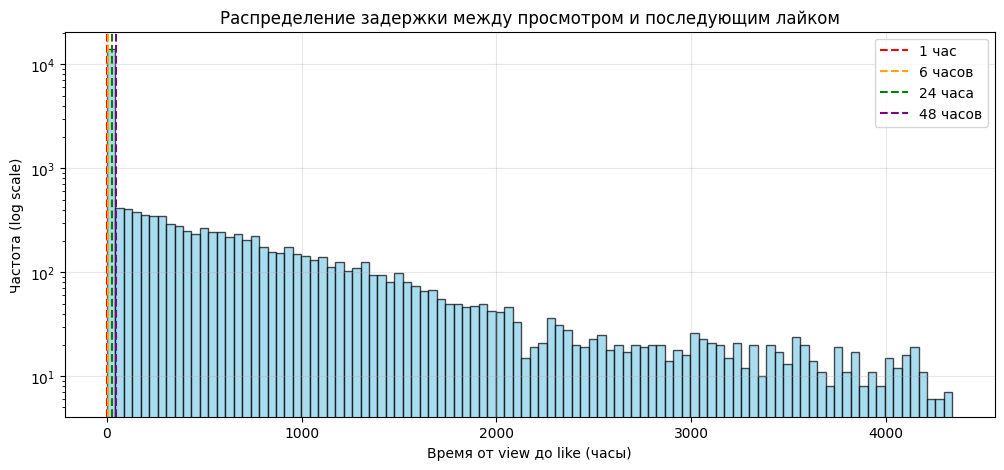

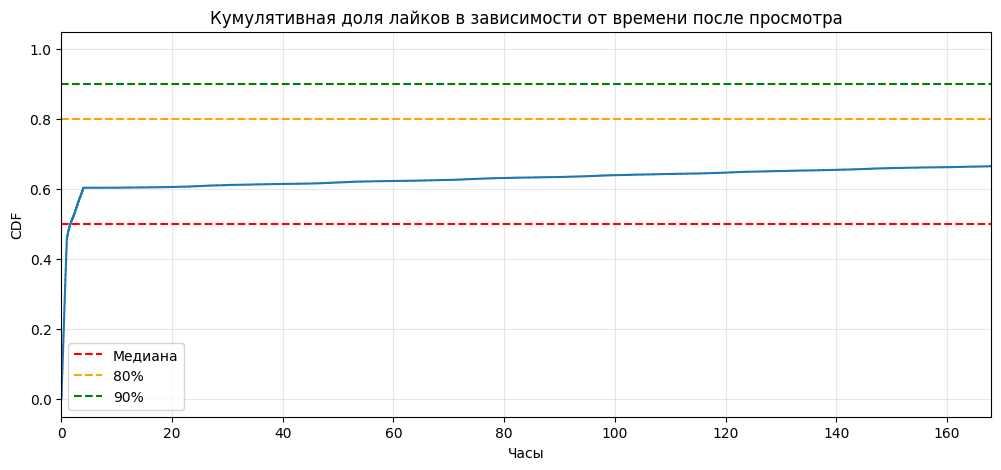

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

views = actions_df[actions_df['action_type'] == 'view'].copy()
likes = actions_df[actions_df['action_type'] == 'like'].copy()

likes_by_user_course = {}
for _, row in likes.iterrows():
    key = (row['user_temp_id'], row['course_temp_id'])
    likes_by_user_course.setdefault(key, []).append(row['timestamp'])


time_diffs = []
for _, row in views.iterrows():
    uid, cid, t_view = row['user_temp_id'], row['course_temp_id'], row['timestamp']
    like_times = likes_by_user_course.get((uid, cid), [])
    future_likes = [lt for lt in like_times if lt > t_view]
    if future_likes:
        t_like = min(future_likes)
        diff_hours = (t_like - t_view).total_seconds() / 3600
        time_diffs.append(diff_hours)

print(f"Всего пар view→like: {len(time_diffs)}")
print(f"Медиана: {np.median(time_diffs):.2f} ч")
print(f"90-й перцентиль: {np.percentile(time_diffs, 90):.2f} ч")
print(f"95-й перцентиль: {np.percentile(time_diffs, 95):.2f} ч")
print(f"99-й перцентиль: {np.percentile(time_diffs, 99):.2f} ч")

plt.figure(figsize=(12, 5))
plt.hist(time_diffs, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.yscale('log')
plt.xlabel('Время от view до like (часы)')
plt.ylabel('Частота (log scale)')
plt.title('Распределение задержки между просмотром и последующим лайком')
plt.axvline(x=1, color='red', linestyle='--', label='1 час')
plt.axvline(x=6, color='orange', linestyle='--', label='6 часов')
plt.axvline(x=24, color='green', linestyle='--', label='24 часа')
plt.axvline(x=48, color='purple', linestyle='--', label='48 часов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Также построим CDF
plt.figure(figsize=(12, 5))
sorted_diffs = np.sort(time_diffs)
cdf = np.arange(1, len(sorted_diffs)+1) / len(sorted_diffs)
plt.plot(sorted_diffs, cdf, drawstyle='steps-post')
plt.xlim(0, 168)  # первые 7 дней
plt.xlabel('Часы')
plt.ylabel('CDF')
plt.title('Кумулятивная доля лайков в зависимости от времени после просмотра')
plt.axhline(y=0.5, color='red', linestyle='--', label='Медиана')
plt.axhline(y=0.8, color='orange', linestyle='--', label='80%')
plt.axhline(y=0.9, color='green', linestyle='--', label='90%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
tag_registry = {tag['tag_id']: tag['slug'] for tag in junction['tag_registry']}

course_tags = {}
for pair in junction['course_tag_pairs']:
    cid = pair['course_temp_id']
    tag_slug = tag_registry[pair['tag_id']]
    if cid not in course_tags:
        course_tags[cid] = set()
    course_tags[cid].add(tag_slug)

user_tags = {}
for pair in junction['user_tag_pairs']:
    uid = pair['user_temp_id']
    tag_slug = tag_registry[pair['tag_id']]
    if uid not in user_tags:
        user_tags[uid] = set()
    user_tags[uid].add(tag_slug)

course_difficulty = {}
course_domain = {}
course_age = {}
for _, row in courses_df.iterrows():
    course_difficulty[row['temp_id']] = row['difficulty']
    course_domain[row['temp_id']] = row.get('primary_domain_id', None)
    course_age[row['temp_id']] = row['age_days']

user_preferred_difficulty = {}
for _, row in users_df.iterrows():
    user_preferred_difficulty[row['temp_id']] = row['preferred_difficulty']

In [29]:
tag_names = {}
for tag in taxonomy['tags']:
    tag_names[tag['slug']] = tag['name']

tag_embeddings = {}
tag_slugs_list = list(tag_names.keys())
tag_texts = [tag_names[slug] for slug in tag_slugs_list]
tag_emb_array = model_emb.encode(tag_texts, show_progress_bar=True)
for slug, emb in zip(tag_slugs_list, tag_emb_array):
    tag_embeddings[slug] = emb

print(f"Эмбеддинги тегов: {len(tag_embeddings)} шт.")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Эмбеддинги тегов: 28 шт.


In [30]:
tag2domain = {t['slug']: t['domain_id'] for t in taxonomy['tags']}
tag2cluster = {t['slug']: t['cluster_id'] for t in taxonomy['tags']}

cooc = {}
for r in taxonomy['co_occurrence']:
    a, b, w = r['tag_a'], r['tag_b'], r['weight']
    cooc[(a,b)] = w
    cooc[(b,a)] = w

all_domains = ['ml_core', 'data_eng', 'mlops_delivery', 'product_analytics']
all_clusters = ['fundamentals', 'tech_stack', 'delivery', 'business_logic']
all_difficulties = ['beginner', 'intermediate', 'advanced']

In [31]:
course_views_counter = defaultdict(list)
course_likes_counter = defaultdict(list)

In [32]:
def count_window(event_list, current_ts, days):
    if not event_list:
        return 0
    cutoff = current_ts - timedelta(days=days)
    cnt = 0
    for t in reversed(event_list):
        if t >= cutoff and t < current_ts:
            cnt += 1
        elif t < cutoff:
            break
    return cnt

In [33]:
def compute_course_popularity_weight(views_count, likes_count, created_at, current_time,
                                     weights=None, half_life_days=90, scale=1000):
    if weights is None:
        weights = {'views': 0.2, 'likes': 0.5, 'novelty': 0.3}
    age_days = (current_time - created_at).days
    if age_days <= 0:
        novelty_score = scale
    else:
        decay = math.exp(-age_days * 0.693147 / half_life_days)
        novelty_score = decay * scale
    total = (views_count * weights['views'] +
             likes_count * weights['likes'] +
             novelty_score * weights['novelty'])
    return round(total, 4)

In [34]:
def compute_tag_entropy(tag_counts):
    total = sum(tag_counts.values())
    if total == 0:
        return 0.0
    entropy = 0.0
    for count in tag_counts.values():
        if count > 0:
            p = count / total
            entropy -= p * math.log(p)
    return entropy

In [35]:
def compute_dynamic_user_emb(uid, history_views, T, course_embeddings, decay_days=30):
    if not history_views:
        return np.zeros(len(next(iter(course_embeddings.values()))))
    embs = []
    weights = []
    for ts, cid, _ in history_views:
        if ts >= T:
            continue
        days_ago = (T - ts).days
        w = math.exp(-max(days_ago, 0) / decay_days)
        if cid in course_embeddings:
            embs.append(course_embeddings[cid])
            weights.append(w)
    if not embs:
        return np.zeros(len(next(iter(course_embeddings.values()))))
    weights = np.array(weights)
    weights = weights / weights.sum()
    user_emb = np.average(embs, axis=0, weights=weights)
    return user_emb

In [36]:
def get_cosine_distance(uid, cid, cosine_dist_dict):
    key = (uid, cid)
    if key in cosine_dist_dict:
        return cosine_dist_dict[key]
    user_dists = [v for (u, c), v in cosine_dist_dict.items() if u == uid]
    if user_dists:
        return np.mean(user_dists)
    return 0.5

In [37]:
def sample_candidates(uid, T, history, future, user_emb_T, course_embeddings, tag_embeddings,
                      all_courses, hard_neg_count=20, random_neg_count=5):
    pos_courses = set(future['course_temp_id'].unique())

    emb = user_emb_T
    if emb is None or np.linalg.norm(emb) == 0:
        u_tags = user_tags.get(uid, set())
        tag_embs = [tag_embeddings[t] for t in u_tags if t in tag_embeddings]
        if tag_embs:
            emb = np.mean(tag_embs, axis=0)
        else:
            remaining = [c for c in all_courses if c not in pos_courses]
            random_neg = np.random.choice(remaining, min(random_neg_count, len(remaining)), replace=False)
            return list(pos_courses) + list(random_neg)

    sims = {}
    for cid in all_courses:
        if cid in course_embeddings:
            c_emb = course_embeddings[cid]
            cos_sim = np.dot(emb, c_emb) / (np.linalg.norm(emb) * np.linalg.norm(c_emb) + 1e-8)
            sims[cid] = cos_sim

    sorted_courses = sorted(sims, key=sims.get, reverse=True)

    hard_neg = []
    for c in sorted_courses:
        if c not in pos_courses and c not in hard_neg:
            hard_neg.append(c)
        if len(hard_neg) >= hard_neg_count:
            break

    remaining = [c for c in all_courses if c not in pos_courses and c not in hard_neg]
    random_neg = list(np.random.choice(remaining, min(random_neg_count, len(remaining)), replace=False))

    candidates = list(pos_courses) + hard_neg + random_neg
    return candidates

In [38]:
def build_multiclass_dataset(actions_df, courses_df, users_df, course_embeddings, tag_embeddings,
                             warmup=3, horizon_days=7, max_T_per_user=None,
                             hard_neg_count=20, random_neg_count=5):
    rows = []
    all_courses = courses_df['temp_id'].unique()

    for uid, grp in actions_df.groupby('user_temp_id'):
        grp = grp.sort_values('timestamp').reset_index(drop=True)

        u_tags = user_tags.get(uid, set())
        u_diff = user_preferred_difficulty.get(uid)

        user_views_list = []
        user_likes_list = []
        user_views_history_local = []
        user_tag_counter = defaultdict(int)
        user_course_view_counts_local = defaultdict(int)
        user_course_like_flags_local = set()

        for idx in range(len(grp)):
            row_event = grp.iloc[idx]
            action = row_event['action_type']
            cid = row_event['course_temp_id']
            ts = row_event['timestamp']

            if idx < warmup:
                if action == 'view':
                    user_views_list.append(ts)
                    user_views_history_local.append((ts, cid, course_tags.get(cid, set())))
                    for t in course_tags.get(cid, set()):
                        user_tag_counter[t] += 1
                    course_views_counter[cid].append(ts)
                    user_course_view_counts_local[cid] += 1
                elif action == 'like':
                    user_likes_list.append(ts)
                    course_likes_counter[cid].append(ts)
                    user_course_like_flags_local.add(cid)
                continue

            T = ts
            history = grp[grp['timestamp'] < T]
            future = grp[(grp['timestamp'] > T) &
                         (grp['timestamp'] <= T + timedelta(days=horizon_days))]

            user_views_7d_val = count_window(user_views_list, T, 7)
            user_views_30d_val = count_window(user_views_list, T, 30)
            user_likes_7d_val = count_window(user_likes_list, T, 7)
            user_likes_30d_val = count_window(user_likes_list, T, 30)

            recent_views_7d = [(t, c, tags) for (t, c, tags) in user_views_history_local if t >= T - timedelta(days=7)]
            unique_courses_7d = len({c for (_, c, _) in recent_views_7d})
            unique_tags_7d = len(set().union(*[tags for (_, _, tags) in recent_views_7d]))

            user_views_prev_7d_val = count_window(user_views_list, T - timedelta(days=7), 7)
            user_views_trend_val = (user_views_7d_val + 1) / (user_views_prev_7d_val + 1)

            total_interactions_30d = user_views_30d_val + user_likes_30d_val
            user_like_rate_30d_val = user_likes_30d_val / max(1, total_interactions_30d)

            tag_entropy_val = compute_tag_entropy(user_tag_counter)

            user_domain_set = set()
            for t in u_tags:
                if t in tag2domain:
                    user_domain_set.add(tag2domain[t])
            user_domain_count_val = len(user_domain_set)

            if user_views_list or user_likes_list:
                all_times = sorted(user_views_list + user_likes_list)
                days_since_last = (T - all_times[-1]).days
            else:
                days_since_last = 999

            active_days = set()
            for t_ev in user_views_list + user_likes_list:
                active_days.add(t_ev.date())
            session_length_avg = len(user_views_list) / max(1, len(active_days))

            user_emb_T = compute_dynamic_user_emb(uid, user_views_history_local, T, course_embeddings)

            liked_recently = []
            viewed_recently = []
            liked_recently_tags = []
            for t_ev, c_ev, c_tags_ev in user_views_history_local:
                if t_ev >= T - timedelta(days=30) and c_ev in user_course_like_flags_local:
                    liked_recently.append(c_ev)
                    liked_recently_tags.append(c_tags_ev)
                if t_ev >= T - timedelta(days=7):
                    viewed_recently.append(c_ev)

            candidates = sample_candidates(
                uid, T, history, future, user_emb_T, course_embeddings, tag_embeddings,
                all_courses, hard_neg_count, random_neg_count
            )

            for cid_candidate in candidates:
                target = 1 if cid_candidate in set(future['course_temp_id'].unique()) else 0

                c_tags = course_tags.get(cid_candidate, set())
                c_diff = course_difficulty.get(cid_candidate)
                c_domain = course_domain.get(cid_candidate)
                c_age = course_age.get(cid_candidate, 0)

                common = len(u_tags & c_tags)
                total_tags = len(u_tags) + len(c_tags)
                jaccard = common / max(1, total_tags - common)

                cooc_sum_val = 0.0
                cooc_pairs = 0
                cooc_max_val = 0.0
                for ut in u_tags:
                    for ct in c_tags:
                        w = cooc.get((ut, ct), 0.0)
                        cooc_sum_val += w
                        cooc_pairs += 1
                        cooc_max_val = max(cooc_max_val, w)
                cooc_mean_val = cooc_sum_val / cooc_pairs if cooc_pairs > 0 else 0.0

                user_domains = set()
                for t in u_tags:
                    if t in tag2domain:
                        user_domains.add(tag2domain[t])
                course_domains = set()
                for t in c_tags:
                    if t in tag2domain:
                        course_domains.add(tag2domain[t])
                domain_jaccard_val = len(user_domains & course_domains) / max(1, len(user_domains | course_domains))

                user_clusters = set()
                for t in u_tags:
                    if t in tag2cluster:
                        user_clusters.add(tag2cluster[t])
                course_clusters = set()
                for t in c_tags:
                    if t in tag2cluster:
                        course_clusters.add(tag2cluster[t])
                cluster_jaccard_val = len(user_clusters & course_clusters) / max(1, len(user_clusters | course_clusters))

                primary_domain_match_val = 1 if (c_domain and c_domain in user_domains) else 0

                c_emb = course_embeddings.get(cid_candidate)
                if c_emb is not None and user_emb_T is not None and np.linalg.norm(user_emb_T) > 0:
                    cosine_sim = np.dot(user_emb_T, c_emb) / (np.linalg.norm(user_emb_T) * np.linalg.norm(c_emb) + 1e-8)
                    cosine_dist = 1 - cosine_sim
                    dot_prod = np.dot(user_emb_T, c_emb)
                    l2_dist = np.linalg.norm(user_emb_T - c_emb)
                else:
                    cosine_dist = 0.5
                    dot_prod = 0.0
                    l2_dist = 1.0

                max_cos_to_likes = 0.0
                mean_cos_to_views = 0.0
                if liked_recently and c_emb is not None:
                    liked_embs = [course_embeddings[lc] for lc in liked_recently if lc in course_embeddings]
                    if liked_embs:
                        liked_embs = np.array(liked_embs)
                        sims = np.dot(liked_embs, c_emb) / (np.linalg.norm(liked_embs, axis=1) * np.linalg.norm(c_emb) + 1e-8)
                        max_cos_to_likes = sims.max()
                if viewed_recently and c_emb is not None:
                    viewed_embs = [course_embeddings[vc] for vc in viewed_recently if vc in course_embeddings]
                    if viewed_embs:
                        viewed_embs = np.array(viewed_embs)
                        sims = np.dot(viewed_embs, c_emb) / (np.linalg.norm(viewed_embs, axis=1) * np.linalg.norm(c_emb) + 1e-8)
                        mean_cos_to_views = sims.mean()

                max_jaccard_to_likes = 0.0
                for lt in liked_recently_tags:
                    jac = len(lt & c_tags) / max(1, len(lt | c_tags))
                    max_jaccard_to_likes = max(max_jaccard_to_likes, jac)

                viewed_before = 1 if cid_candidate in [c for _, c, _ in user_views_history_local] else 0
                times_viewed = user_course_view_counts_local.get(cid_candidate, 0)
                liked_before = 1 if cid_candidate in user_course_like_flags_local else 0

                last_interaction_days = 999
                for t_ev, c_ev, _ in reversed(user_views_history_local):
                    if c_ev == cid_candidate:
                        last_interaction_days = (T - t_ev).days
                        break

                diff_match = 1 if (u_diff and u_diff == c_diff) else 0

                course_created_at = T - timedelta(days=c_age)

                course_views_before_T = len([t for t in course_views_counter.get(cid_candidate, []) if t < T])
                course_likes_before_T = len([t for t in course_likes_counter.get(cid_candidate, []) if t < T])
                course_views_7d_val = count_window(course_views_counter.get(cid_candidate, []), T, 7)
                course_views_30d_val = count_window(course_views_counter.get(cid_candidate, []), T, 30)
                course_likes_7d_val = count_window(course_likes_counter.get(cid_candidate, []), T, 7)
                course_likes_30d_val = count_window(course_likes_counter.get(cid_candidate, []), T, 30)

                pop_weight = compute_course_popularity_weight(
                    course_views_before_T, course_likes_before_T,
                    course_created_at, T
                )

                course_like_rate_val = course_likes_before_T / max(1, course_views_before_T + course_likes_before_T)

                course_views_prev_7d_val = count_window(course_views_counter.get(cid_candidate, []),
                                                        T - timedelta(days=7), 7)
                course_trend_val = (course_views_7d_val + 1) / (course_views_prev_7d_val + 1)

                course_age_days_val = (T - course_created_at).days

                row = {
                    'uid': uid,
                    'cid': cid_candidate,
                    'T': T,
                    'group_id': f"{uid}_{T}",
                    'user_views_7d': user_views_7d_val,
                    'user_views_30d': user_views_30d_val,
                    'user_likes_7d': user_likes_7d_val,
                    'user_likes_30d': user_likes_30d_val,
                    'user_unique_courses_7d': unique_courses_7d,
                    'user_unique_tags_7d': unique_tags_7d,
                    'user_activity_ratio_7d_30d': (user_views_7d_val + 1) / (user_views_30d_val + 1),
                    'user_like_rate_30d': user_like_rate_30d_val,
                    'user_tags_entropy': tag_entropy_val,
                    'user_domain_count': user_domain_count_val,
                    'days_since_last_action': days_since_last,
                    'user_views_prev_7d': user_views_prev_7d_val,
                    'user_views_trend': user_views_trend_val,
                    'user_session_length_avg': session_length_avg,
                    'course_popularity_weight': pop_weight,
                    'course_views_7d': course_views_7d_val,
                    'course_views_30d': course_views_30d_val,
                    'course_likes_7d': course_likes_7d_val,
                    'course_likes_30d': course_likes_30d_val,
                    'course_like_rate': course_like_rate_val,
                    'course_trend': course_trend_val,
                    'course_age_days': course_age_days_val,
                    'course_tags_count': len(c_tags),
                    'course_difficulty': c_diff,
                    'course_primary_domain': c_domain,
                    'common_tags': common,
                    'jaccard_tags': jaccard,
                    'cooc_sum': cooc_sum_val,
                    'cooc_mean': cooc_mean_val,
                    'cooc_max': cooc_max_val,
                    'domain_jaccard': domain_jaccard_val,
                    'cluster_jaccard': cluster_jaccard_val,
                    'primary_domain_match': primary_domain_match_val,
                    'cosine_distance': cosine_dist,
                    'dot_product': dot_prod,
                    'l2_distance': l2_dist,
                    'max_cosine_to_recent_likes': max_cos_to_likes,
                    'mean_cosine_to_recent_views': mean_cos_to_views,
                    'max_jaccard_to_recent_likes': max_jaccard_to_likes,
                    'viewed_before': viewed_before,
                    'times_viewed_before': times_viewed,
                    'liked_before': liked_before,
                    'last_interaction_days': last_interaction_days,
                    'difficulty_match': diff_match,
                    'target': target
                }
                rows.append(row)

            if action == 'view':
                user_views_list.append(ts)
                user_views_history_local.append((ts, cid, course_tags.get(cid, set())))
                for t in course_tags.get(cid, set()):
                    user_tag_counter[t] += 1
                course_views_counter[cid].append(ts)
                user_course_view_counts_local[cid] += 1
            elif action == 'like':
                user_likes_list.append(ts)
                course_likes_counter[cid].append(ts)
                user_course_like_flags_local.add(cid)

            if max_T_per_user and idx >= max_T_per_user + warmup - 1:
                break

    return pd.DataFrame(rows)

In [40]:
import pickle

SAVE_DIR = "/content/drive/MyDrive/coursearch/cached_data/"

if os.path.exists(os.path.join(SAVE_DIR, "dataset_candidates.parquet")):
    dataset_df = pd.read_parquet(os.path.join(SAVE_DIR, "dataset_candidates.parquet"))

    with open(os.path.join(SAVE_DIR, "aux_dicts.pkl"), "rb") as f:
        aux = pickle.load(f)

    actions_df = aux['actions_df']
    courses_df = aux['courses_df']
    users_df = aux['users_df']
    course_embeddings = aux['course_embeddings']
    tag_embeddings = aux['tag_embeddings']
    course_tags = aux['course_tags']
    user_tags = aux['user_tags']
    course_difficulty = aux['course_difficulty']
    course_domain = aux['course_domain']
    course_age = aux['course_age']
    user_preferred_difficulty = aux['user_preferred_difficulty']
    tag2domain = aux['tag2domain']
    tag2cluster = aux['tag2cluster']

    print(f"Загружен датасет: {len(dataset_df)} строк")
else:
    print("Кэш не найден, запускаем генерацию...")

Загружен датасет: 719416 строк


In [ ]:
print("Генерация датасета с кандидатами...")
dataset_df = build_multiclass_dataset(
    actions_df, courses_df, users_df, course_embeddings, tag_embeddings,
    warmup=3, horizon_days=7, max_T_per_user=30,
    hard_neg_count=20, random_neg_count=5
)
print(f"Датасет создан: {dataset_df.shape}")
print(f"Распределение target:\n{dataset_df['target'].value_counts(normalize=True)}")

In [42]:
SAVE_DIR = "/content/drive/MyDrive/coursearch/cached_data/"
os.makedirs(SAVE_DIR, exist_ok=True)

dataset_df.to_parquet(os.path.join(SAVE_DIR, "dataset_candidates.parquet"), index=False)

aux_objects = {
    "actions_df": actions_df,
    "courses_df": courses_df,
    "users_df": users_df,
    "course_embeddings": course_embeddings,
    "tag_embeddings": tag_embeddings,
    "course_tags": course_tags,
    "user_tags": user_tags,
    "course_difficulty": course_difficulty,
    "course_domain": course_domain,
    "course_age": course_age,
    "user_preferred_difficulty": user_preferred_difficulty,
    "tag2domain": tag2domain,
    "tag2cluster": tag2cluster,
    "cooc": cooc,
}

with open(os.path.join(SAVE_DIR, "aux_dicts.pkl"), "wb") as f:
    pickle.dump(aux_objects, f)

print(f"Сохранено {len(aux_objects)} объектов")

KeyboardInterrupt: 

In [43]:
dataset_df['course_difficulty'] = dataset_df['course_difficulty'].fillna('unknown')
le_difficulty = LabelEncoder()
dataset_df['course_difficulty_encoded'] = le_difficulty.fit_transform(dataset_df['course_difficulty'])

dataset_df['course_primary_domain'] = dataset_df['course_primary_domain'].fillna('unknown')
le_domain = LabelEncoder()
dataset_df['course_primary_domain_encoded'] = le_domain.fit_transform(dataset_df['course_primary_domain'])

In [44]:
feature_cols = [
    'user_views_7d', 'user_views_30d', 'user_likes_7d', 'user_likes_30d',
    'user_unique_courses_7d', 'user_unique_tags_7d',
    'user_activity_ratio_7d_30d', 'user_like_rate_30d',
    'user_tags_entropy', 'user_domain_count',
    'days_since_last_action', 'user_views_prev_7d', 'user_views_trend',
    'user_session_length_avg',
    'course_popularity_weight', 'course_views_7d', 'course_views_30d',
    'course_likes_7d', 'course_likes_30d', 'course_like_rate', 'course_trend',
    'course_age_days', 'course_tags_count',
    'course_difficulty_encoded', 'course_primary_domain_encoded',
    'common_tags', 'jaccard_tags',
    'cooc_sum', 'cooc_mean', 'cooc_max',
    'domain_jaccard', 'cluster_jaccard', 'primary_domain_match',
    'cosine_distance', 'dot_product', 'l2_distance',
    'max_cosine_to_recent_likes', 'mean_cosine_to_recent_views',
    'max_jaccard_to_recent_likes',
    'viewed_before', 'times_viewed_before', 'liked_before',
    'last_interaction_days', 'difficulty_match'
]
print(f"Всего признаков: {len(feature_cols)}")

Всего признаков: 44


In [45]:
X = dataset_df[feature_cols].copy()
y = dataset_df['target'].values

In [46]:

dataset_df = dataset_df.sort_values('T')
split_date = dataset_df['T'].quantile(0.8)
train_mask = dataset_df['T'] < split_date
val_mask = dataset_df['T'] >= split_date

In [47]:

train_df = dataset_df.loc[train_mask].sort_values('group_id').copy()
val_df   = dataset_df.loc[val_mask].sort_values('group_id').copy()

X_train = train_df[feature_cols].copy()
y_train = train_df['target'].values
X_val   = val_df[feature_cols].copy()
y_val   = val_df['target'].values

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (575523, 44), Val: (143893, 44)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [48]:
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

model_clf = CatBoostClassifier(
    loss_function='Logloss',
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    eval_metric='AUC',
    early_stopping_rounds=50,
    auto_class_weights='Balanced',
    verbose=100
)
model_clf.fit(train_pool, eval_set=val_pool)

0:	test: 0.8393564	best: 0.8393564 (0)	total: 626ms	remaining: 10m 25s
100:	test: 0.8782462	best: 0.8782462 (100)	total: 32.4s	remaining: 4m 48s
200:	test: 0.8832201	best: 0.8832201 (200)	total: 1m 3s	remaining: 4m 13s
300:	test: 0.8853914	best: 0.8853914 (300)	total: 1m 35s	remaining: 3m 41s
400:	test: 0.8870671	best: 0.8870671 (400)	total: 2m 6s	remaining: 3m 8s
500:	test: 0.8881408	best: 0.8881408 (500)	total: 2m 36s	remaining: 2m 35s
600:	test: 0.8893133	best: 0.8893135 (599)	total: 3m 8s	remaining: 2m 4s
700:	test: 0.8899914	best: 0.8899914 (700)	total: 3m 38s	remaining: 1m 33s
800:	test: 0.8905326	best: 0.8905326 (800)	total: 4m 12s	remaining: 1m 2s
900:	test: 0.8909763	best: 0.8909844 (891)	total: 4m 42s	remaining: 31.1s
999:	test: 0.8914000	best: 0.8914052 (998)	total: 5m 13s	remaining: 0us

bestTest = 0.8914051802
bestIteration = 998

Shrink model to first 999 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [49]:
from sklearn.metrics import precision_score, recall_score

y_pred_proba = model_clf.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred_proba)
pr_auc = average_precision_score(y_val, y_pred_proba)
print(f"CatBoost Classifier: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

val_df_clf = val_df.copy()
val_df_clf['score'] = y_pred_proba

precisions = []
recalls = []
ndcgs = []
for gid in val_df_clf['group_id'].unique():
    group = val_df_clf[val_df_clf['group_id'] == gid].sort_values('score', ascending=False)
    top10 = group.head(10)
    y_true = top10['target'].values
    y_pred_binary = (top10['score'] > 0.5).astype(int)
    precisions.append(precision_score(y_true, y_pred_binary, zero_division=0))
    recalls.append(recall_score(y_true, y_pred_binary, zero_division=0))

    true_rel = group['target'].values.reshape(1, -1)
    pred_rel = group['score'].values.reshape(1, -1)
    ndcgs.append(ndcg_score(true_rel, pred_rel, k=10))

print(f"Classifier Precision@10: {np.mean(precisions):.4f}")
print(f"Classifier Recall@10:    {np.mean(recalls):.4f}")
print(f"Classifier NDCG@10:      {np.mean(ndcgs):.4f}")

CatBoost Classifier: ROC-AUC=0.8914, PR-AUC=0.8733
Classifier Precision@10: 0.8962
Classifier Recall@10:    0.9543
Classifier NDCG@10:      0.9198


In [51]:
importances_rank = model_clf.get_feature_importance(data=train_pool, prettified=True)
print(importances_rank.head(20))

                       Feature Id  Importances
0                 cosine_distance    16.142371
1               course_tags_count    11.630930
2                   user_views_7d     7.856704
3                     l2_distance     7.013851
4                 course_age_days     6.243030
5          user_unique_courses_7d     5.305904
6        course_popularity_weight     4.927128
7            primary_domain_match     4.379373
8                 course_views_7d     3.252887
9               user_tags_entropy     2.969538
10                 domain_jaccard     2.620940
11                    dot_product     2.579406
12               course_like_rate     2.258844
13  course_primary_domain_encoded     2.055955
14                   course_trend     1.623542
15              user_domain_count     1.578919
16        user_session_length_avg     1.541685
17                       cooc_max     1.528829
18               course_views_30d     1.446277
19                      cooc_mean     1.268671


In [52]:

train_pool_rank = Pool(X_train, y_train, group_id=train_df['group_id'].values)
val_pool_rank = Pool(X_val, y_val, group_id=val_df['group_id'].values)

model_rank = CatBoostRanker(
    loss_function='YetiRank',
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    eval_metric='NDCG:top=10',
    early_stopping_rounds=50,
    verbose=100,
    custom_metric=['NDCG:top=5', 'MAP:top=10']
)
model_rank.fit(train_pool_rank, eval_set=val_pool_rank)

0:	test: 0.8416845	best: 0.8416845 (0)	total: 1.14s	remaining: 18m 56s


KeyboardInterrupt: 

In [53]:
y_pred_scores = model_rank.predict(X_val)
roc_auc = roc_auc_score(y_val, y_pred_scores)
pr_auc = average_precision_score(y_val, y_pred_scores)
print(f"CatBoost Ranker: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

val_df_rank = val_df.copy()
val_df_rank['score'] = y_pred_scores

precisions_r = []
recalls_r = []
ndcgs_r = []
for gid in val_df_rank['group_id'].unique():
    group = val_df_rank[val_df_rank['group_id'] == gid].sort_values('score', ascending=False)
    top10 = group.head(10)
    y_true = top10['target'].values
    y_pred_binary = (top10['score'] > 0.5).astype(int)
    precisions_r.append(precision_score(y_true, y_pred_binary, zero_division=0))
    recalls_r.append(recall_score(y_true, y_pred_binary, zero_division=0))

    true_rel = group['target'].values.reshape(1, -1)
    pred_rel = group['score'].values.reshape(1, -1)
    ndcgs_r.append(ndcg_score(true_rel, pred_rel, k=10))

print(f"Ranker Precision@10: {np.mean(precisions_r):.4f}")
print(f"Ranker Recall@10:    {np.mean(recalls_r):.4f}")
print(f"Ranker NDCG@10:      {np.mean(ndcgs_r):.4f}")

CatBoostError: There is no trained model to use predict(). Use fit() to train model. Then use this method.

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/coursearch/model_export_v2"
os.makedirs(MODEL_DIR, exist_ok=True)

model_rank.save_model(os.path.join(MODEL_DIR, "catboost_ranker.cbm"))

with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open('../apps/ml-service/models/view_ranker/le_difficulty.pkl', 'wb') as f:
    pickle.dump(le_difficulty, f)
with open('../apps/ml-service/models/view_ranker/le_domain.pkl', 'wb') as f:
    pickle.dump(le_domain, f)

with open(os.path.join(MODEL_DIR, "feature_cols.json"), "w") as f:
    json.dump(feature_cols, f, indent=2)

model_metadata = {
    'model_type': 'CatBoostRanker',
    'loss_function': 'YetiRank',
    'feature_cols': feature_cols,
    'training_date': datetime.now().isoformat(),
    'roc_auc': float(roc_auc_rank) if 'roc_auc_rank' in dir() else None,
    'pr_auc': float(pr_auc_rank) if 'pr_auc_rank' in dir() else None,
    'ndcg@10': float(np.mean(ndcg_scores)) if 'ndcg_scores' in dir() else None,
    'iterations': model_rank.get_params().get('iterations'),
    'learning_rate': model_rank.get_params().get('learning_rate'),
    'depth': model_rank.get_params().get('depth')
}

with open(os.path.join(MODEL_DIR, "model_metadata.json"), "w") as f:
    json.dump(model_metadata, f, indent=2)

inference_code = """
import json
import pickle
import pandas as pd
import numpy as np
from catboost import CatBoostRanker

model = CatBoostRanker()
model.load_model("catboost_ranker.cbm")
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open("feature_cols.json", "r") as f:
    feature_cols = json.load(f)

print("Модель и артефакты загружены.")
"""

with open(os.path.join(MODEL_DIR, "inference_example.py"), "w") as f:
    f.write(inference_code)

print(f"Модель сохранена в: {MODEL_DIR}")
for file in os.listdir(MODEL_DIR):
    print(f"  - {file}")

In [ ]:
importances_rank = model_rank.get_feature_importance(data=train_pool_rank, prettified=True)
print(importances_rank.head(20))

# Like Ranker Model Pipeline

In [96]:
import bisect

# Параметр окна (часы)
LOOKAHEAD_HOURS = 6

views = actions_df[actions_df['action_type'] == 'view'].copy()
likes = actions_df[actions_df['action_type'] == 'like'].copy()
views_sorted = views.sort_values(['user_temp_id', 'course_temp_id', 'timestamp']).reset_index(drop=True)

likes_dict = defaultdict(list)
for _, row in likes.iterrows():
    uid, cid, ts = row['user_temp_id'], row['course_temp_id'], row['timestamp']
    if pd.notna(ts):
        likes_dict[(uid, cid)].append(ts)
for k in likes_dict:
    likes_dict[k].sort()

targets = []
for idx, row in views_sorted.iterrows():
    uid, cid, t_view = row['user_temp_id'], row['course_temp_id'], row['timestamp']
    like_times = likes_dict.get((uid, cid), [])
    # Находим первый лайк после просмотра
    future_likes = [lt for lt in like_times if lt > t_view]
    if not future_likes:
        targets.append(0)
    else:
        first_like = min(future_likes)
        delta_hours = (first_like - t_view).total_seconds() / 3600
        targets.append(1 if delta_hours <= LOOKAHEAD_HOURS else 0)

views_sorted['target'] = targets
post_view_df = views_sorted[['user_temp_id', 'course_temp_id', 'timestamp', 'target']].copy()
print(f"Target после ограничения окном {LOOKAHEAD_HOURS} ч:")
print(post_view_df['target'].value_counts(normalize=True))

Target после ограничения окном 6 ч:
target
0    0.779478
1    0.220522
Name: proportion, dtype: float64


In [97]:
def build_post_view_features_v3(actions_df, post_view_df, course_embeddings, tag_embeddings,
                                course_tags, user_tags, tag2domain, tag2cluster, cooc,
                                course_difficulty, course_domain, course_age,
                                user_preferred_difficulty, session_gap_hours=2):
    target_dict = {}
    for _, rec in post_view_df.iterrows():
        key = (rec['user_temp_id'], rec['course_temp_id'], rec['timestamp'])
        target_dict[key] = rec['target']

    rows = []
    all_events = actions_df.sort_values('timestamp').reset_index(drop=True)
    views_to_process = set(target_dict.keys())

    user_views_history = defaultdict(list)
    user_likes_list = defaultdict(list)
    user_course_view_counts = defaultdict(lambda: defaultdict(int))
    user_course_like_flags = defaultdict(set)
    course_views_timestamps = defaultdict(list)
    course_likes_timestamps = defaultdict(list)

    session_start = {}
    session_views_count = defaultdict(int)
    session_likes_count = defaultdict(int)
    session_view_pos = {}
    last_event_time = {}
    last_like_time = {}
    last_3_views_likes = defaultdict(list)

    processed = 0
    total = len(views_to_process)

    for idx in range(len(all_events)):
        ev = all_events.iloc[idx]
        uid = ev['user_temp_id']
        cid = ev['course_temp_id']
        ts = ev['timestamp']
        etype = ev['action_type']

        prev_time = last_event_time.get(uid)
        if prev_time is None or (ts - prev_time).total_seconds() > session_gap_hours * 3600:
            session_start[uid] = ts
            session_views_count[uid] = 0
            session_likes_count[uid] = 0
            session_view_pos[uid] = 0
            last_3_views_likes[uid] = []


        if etype == 'view':
            session_views_count[uid] += 1
            session_view_pos[uid] = session_views_count[uid]
        else:
            session_likes_count[uid] += 1
            last_like_time[uid] = ts

        if etype == 'view':
            duration = ev.get('duration_seconds', None)
            if duration is None:
                duration = 30  # fallback
            user_views_history[uid].append((ts, cid, course_tags.get(cid, set()), duration))
            user_course_view_counts[uid][cid] += 1
            course_views_timestamps[cid].append(ts)
        else:
            user_likes_list[uid].append(ts)
            user_course_like_flags[uid].add(cid)
            course_likes_timestamps[cid].append(ts)

        last_event_time[uid] = ts

        key = (uid, cid, ts)
        if key in views_to_process:
            T = ts


            session_duration_hours = (T - session_start[uid]).total_seconds() / 3600
            session_views_so_far = session_views_count[uid]
            session_likes_so_far = session_likes_count[uid]
            session_total_events = session_views_so_far + session_likes_so_far
            session_like_rate = session_likes_so_far / max(1, session_total_events)
            view_pos_in_session = session_view_pos[uid]


            time_since_last_like_seconds = 9999
            if uid in last_like_time:
                time_since_last_like_seconds = (T - last_like_time[uid]).total_seconds()


            likes_last_3 = sum(last_3_views_likes[uid][-3:]) if last_3_views_likes[uid] else 0


            is_repeat_view = 1 if any(c == cid and t < T for t, c, _, _ in user_views_history[uid]) else 0

            hour_of_day = T.hour
            is_weekend = 1 if T.weekday() >= 5 else 0


            u_views = [t for t, _, _, _ in user_views_history[uid]]
            u_likes = user_likes_list[uid]

            user_views_1h = len([t for t in u_views if T - timedelta(hours=1) <= t < T])
            user_views_4h = len([t for t in u_views if T - timedelta(hours=4) <= t < T])
            user_views_7d = count_window(u_views, T, 7)
            user_views_30d = count_window(u_views, T, 30)
            user_likes_7d = count_window(u_likes, T, 7)
            user_likes_30d = count_window(u_likes, T, 30)

            recent_7d = [(t, c, tags) for t, c, tags, _ in user_views_history[uid] if t >= T - timedelta(days=7)]
            unique_courses_7d = len(set(c for _, c, _ in recent_7d))
            unique_tags_7d = len(set().union(*[tags for _, _, tags in recent_7d]))

            user_views_prev_7d = count_window(u_views, T - timedelta(days=7), 7)
            user_views_trend = (user_views_7d + 1) / (user_views_prev_7d + 1)

            total_inter_30d = user_views_30d + user_likes_30d
            user_like_rate_30d = user_likes_30d / max(1, total_inter_30d)

            tag_counter = defaultdict(int)
            for _, _, tags, _ in user_views_history[uid]:
                for t in tags:
                    tag_counter[t] += 1
            user_tags_entropy = compute_tag_entropy(tag_counter)

            u_tags = user_tags.get(uid, set())
            user_domain_set = set(tag2domain.get(t) for t in u_tags if t in tag2domain)
            user_domain_count = len(user_domain_set)

            days_since_last = 999
            if u_views or u_likes:
                days_since_last = (T - max(u_views + u_likes)).days

            active_days = set(d.date() for d in u_views + u_likes)
            session_length_avg = len(u_views) / max(1, len(active_days))


            user_emb_T = compute_dynamic_user_emb(uid, [(t, c, tags) for t, c, tags, _ in user_views_history[uid]],
                                                  T + timedelta(seconds=1), course_embeddings)


            viewed_before = 1 if any(c == cid and t < T for t, c, _, _ in user_views_history[uid]) else 0
            times_viewed_before = user_course_view_counts[uid].get(cid, 0) - 1
            liked_before = 1 if cid in user_course_like_flags[uid] else 0

            last_inter = 999
            for t, c, _, _ in reversed(user_views_history[uid]):
                if c == cid and t < T:
                    last_inter = (T - t).days
                    break

            view_number = user_course_view_counts[uid][cid]
            prev_view_time = None
            for t, c, _, _ in reversed(user_views_history[uid]):
                if c == cid and t < T:
                    prev_view_time = t
                    break
            hours_since_prev_view = (T - prev_view_time).total_seconds() / 3600 if prev_view_time else 999

            session_activity_30min = len([t for t in u_views + u_likes if T - timedelta(minutes=30) <= t <= T])

            liked_courses = user_course_like_flags[uid]
            viewed_courses = set(c for _, c, _, _ in user_views_history[uid])
            user_conversion_ratio = len(liked_courses) / len(viewed_courses) if viewed_courses else 0.0


            c_tags = course_tags.get(cid, set())
            c_diff = course_difficulty.get(cid)
            c_domain = course_domain.get(cid)
            c_age = course_age.get(cid, 0)

            common = len(u_tags & c_tags)
            jaccard = common / max(1, len(u_tags) + len(c_tags) - common)

            cooc_sum, cooc_pairs, cooc_max = 0.0, 0, 0.0
            for ut in u_tags:
                for ct in c_tags:
                    w = cooc.get((ut, ct), 0.0)
                    cooc_sum += w
                    cooc_pairs += 1
                    cooc_max = max(cooc_max, w)
            cooc_mean = cooc_sum / cooc_pairs if cooc_pairs else 0.0

            course_domains = set(tag2domain.get(t) for t in c_tags if t in tag2domain)
            domain_jaccard = len(user_domain_set & course_domains) / max(1, len(user_domain_set | course_domains))

            user_clusters = set(tag2cluster.get(t) for t in u_tags if t in tag2cluster)
            course_clusters = set(tag2cluster.get(t) for t in c_tags if t in tag2cluster)
            cluster_jaccard = len(user_clusters & course_clusters) / max(1, len(user_clusters | course_clusters))

            primary_domain_match = 1 if (c_domain and c_domain in user_domain_set) else 0


            c_emb = course_embeddings.get(cid)
            if c_emb is not None and np.linalg.norm(user_emb_T) > 0:
                cosine_sim = np.dot(user_emb_T, c_emb) / (np.linalg.norm(user_emb_T)*np.linalg.norm(c_emb)+1e-8)
                cosine_dist = 1 - cosine_sim
                dot_prod = np.dot(user_emb_T, c_emb)
                l2_dist = np.linalg.norm(user_emb_T - c_emb)
            else:
                cosine_dist, dot_prod, l2_dist = 0.5, 0.0, 1.0

            liked_recently, liked_tags, viewed_recently = [], [], []
            for t, c, ct, _ in user_views_history[uid]:
                if t >= T - timedelta(days=30) and c in user_course_like_flags[uid]:
                    liked_recently.append(c)
                    liked_tags.append(ct)
                if t >= T - timedelta(days=7) and c != cid:
                    viewed_recently.append(c)

            max_cos_likes = 0.0
            if liked_recently and c_emb is not None:
                embs = [course_embeddings[c] for c in liked_recently if c in course_embeddings]
                if embs:
                    arr = np.array(embs)
                    sims = np.dot(arr, c_emb) / (np.linalg.norm(arr,axis=1)*np.linalg.norm(c_emb)+1e-8)
                    max_cos_likes = sims.max()
            mean_cos_views = 0.0
            if viewed_recently and c_emb is not None:
                embs = [course_embeddings[c] for c in viewed_recently if c in course_embeddings]
                if embs:
                    arr = np.array(embs)
                    sims = np.dot(arr, c_emb) / (np.linalg.norm(arr,axis=1)*np.linalg.norm(c_emb)+1e-8)
                    mean_cos_views = sims.mean()

            max_jac_likes = 0.0
            for lt in liked_tags:
                jac = len(lt & c_tags) / max(1, len(lt | c_tags))
                max_jac_likes = max(max_jac_likes, jac)


            course_created_at = T - timedelta(days=c_age)
            cv_before = len([t for t in course_views_timestamps.get(cid,[]) if t < T])
            cl_before = len([t for t in course_likes_timestamps.get(cid,[]) if t < T])
            cv_7d = count_window(course_views_timestamps.get(cid,[]), T, 7)
            cv_30d = count_window(course_views_timestamps.get(cid,[]), T, 30)
            cl_7d = count_window(course_likes_timestamps.get(cid,[]), T, 7)
            cl_30d = count_window(course_likes_timestamps.get(cid,[]), T, 30)

            pop_weight = compute_course_popularity_weight(cv_before, cl_before, course_created_at, T)
            course_like_rate = cl_before / max(1, cv_before + cl_before)
            cv_prev_7d = count_window(course_views_timestamps.get(cid,[]), T - timedelta(days=7), 7)
            course_trend = (cv_7d + 1) / (cv_prev_7d + 1)
            course_age_days = (T - course_created_at).days

            diff_match = 1 if (user_preferred_difficulty.get(uid) == c_diff) else 0


            duration_seconds = 30
            for t, c, _, dur in user_views_history[uid]:
                if c == cid and t == T:
                    duration_seconds = dur
                    break

            row = {
                'uid': uid, 'cid': cid, 'T': T,
                'duration_seconds': duration_seconds,
                'time_since_last_like_seconds': time_since_last_like_seconds,
                'likes_in_last_3_views': likes_last_3,
                'is_repeat_view': is_repeat_view,
                'hour_of_day': hour_of_day,
                'is_weekend': is_weekend,
                'session_duration_hours': session_duration_hours,
                'session_views': session_views_so_far,
                'session_likes': session_likes_so_far,
                'session_like_rate': session_like_rate,
                'view_pos_in_session': view_pos_in_session,
                'user_views_1h': user_views_1h,
                'user_views_4h': user_views_4h,
                'user_views_7d': user_views_7d,
                'user_views_30d': user_views_30d,
                'user_likes_7d': user_likes_7d,
                'user_likes_30d': user_likes_30d,
                'user_unique_courses_7d': unique_courses_7d,
                'user_unique_tags_7d': unique_tags_7d,
                'user_activity_ratio_7d_30d': (user_views_7d+1)/(user_views_30d+1),
                'user_like_rate_30d': user_like_rate_30d,
                'user_tags_entropy': user_tags_entropy,
                'user_domain_count': user_domain_count,
                'days_since_last_action': days_since_last,
                'user_views_prev_7d': user_views_prev_7d,
                'user_views_trend': user_views_trend,
                'user_session_length_avg': session_length_avg,
                'user_session_activity_30min': session_activity_30min,
                'user_conversion_ratio': user_conversion_ratio,
                'course_popularity_weight': pop_weight,
                'course_views_7d': cv_7d,
                'course_views_30d': cv_30d,
                'course_likes_7d': cl_7d,
                'course_likes_30d': cl_30d,
                'course_like_rate': course_like_rate,
                'course_trend': course_trend,
                'course_age_days': course_age_days,
                'course_tags_count': len(c_tags),
                'course_difficulty': c_diff,
                'course_primary_domain': c_domain,
                'common_tags': common,
                'jaccard_tags': jaccard,
                'cooc_sum': cooc_sum,
                'cooc_mean': cooc_mean,
                'cooc_max': cooc_max,
                'domain_jaccard': domain_jaccard,
                'cluster_jaccard': cluster_jaccard,
                'primary_domain_match': primary_domain_match,
                'cosine_distance': cosine_dist,
                'dot_product': dot_prod,
                'l2_distance': l2_dist,
                'max_cosine_to_recent_likes': max_cos_likes,
                'mean_cosine_to_recent_views': mean_cos_views,
                'max_jaccard_to_recent_likes': max_jac_likes,
                'viewed_before': viewed_before,
                'times_viewed_before': times_viewed_before,
                'liked_before': liked_before,
                'last_interaction_days': last_inter,
                'view_number': view_number,
                'hours_since_prev_view': hours_since_prev_view,
                'difficulty_match': diff_match,
                'target': target_dict[key]
            }
            rows.append(row)
            processed += 1
            if processed % 10000 == 0:
                print(f"Обработано {processed}/{total} view-событий")


            last_3_views_likes[uid].append(target_dict[key])
            if len(last_3_views_likes[uid]) > 3:
                last_3_views_likes[uid].pop(0)

    return pd.DataFrame(rows)

In [103]:
SAVE_DIR_LIKE = "/content/drive/MyDrive/coursearch/cached_data/like_ranker/"
if os.path.exists(os.path.join(SAVE_DIR_LIKE, "post_view_features.parquet")):
    print("Загрузка кэшированных данных Like Ranker...")
    post_view_features_df_v3 = pd.read_parquet(os.path.join(SAVE_DIR_LIKE, "post_view_features.parquet"))

    if os.path.exists(os.path.join(SAVE_DIR_LIKE, "label_encoder_difficulty.pkl")):
        with open(os.path.join(SAVE_DIR_LIKE, "label_encoder_difficulty.pkl"), "rb") as f:
            le_diff_post = pickle.load(f)
    if os.path.exists(os.path.join(SAVE_DIR_LIKE, "label_encoder_domain.pkl")):
        with open(os.path.join(SAVE_DIR_LIKE, "label_encoder_domain.pkl"), "rb") as f:
            le_domain_post = pickle.load(f)
    if os.path.exists(os.path.join(SAVE_DIR_LIKE, "feature_cols_v3.json")):
        with open(os.path.join(SAVE_DIR_LIKE, "feature_cols_v3.json"), "r") as f:
            feature_cols_v3 = json.load(f)
    if os.path.exists(os.path.join(SAVE_DIR_LIKE, "scaler_v3.pkl")):
        with open(os.path.join(SAVE_DIR_LIKE, "scaler_v3.pkl"), "rb") as f:
            scaler_v3 = pickle.load(f)

    print(f"Загружено {post_view_features_df_v3.shape[0]} строк")
else:
    print("Генерация признаков v3 с сессионными фичами...")
    post_view_features_df_v3 = build_post_view_features_v3(
        actions_df, post_view_df, course_embeddings, tag_embeddings,
        course_tags, user_tags, tag2domain, tag2cluster, cooc,
        course_difficulty, course_domain, course_age,
        user_preferred_difficulty
    )
    print(f"Размер: {post_view_features_df_v3.shape}")

Загрузка кэшированных данных Like Ranker...
Загружено 62225 строк


In [66]:
print("Генерация признаков v3 с сессионными фичами")
post_view_features_df_v3 = build_post_view_features_v3(
    actions_df, post_view_df, course_embeddings, tag_embeddings,
    course_tags, user_tags, tag2domain, tag2cluster, cooc,
    course_difficulty, course_domain, course_age,
    user_preferred_difficulty
)
print(f"Размер: {post_view_features_df_v3.shape}")

Генерация признаков v3 с сессионными фичами
Обработано 10000/62070 view-событий
Обработано 20000/62070 view-событий
Обработано 30000/62070 view-событий
Обработано 40000/62070 view-событий
Обработано 50000/62070 view-событий
Обработано 60000/62070 view-событий
Размер: (62225, 65)


In [104]:
SAVE_DIR_LIKE = "/content/drive/MyDrive/coursearch/cached_data/like_ranker/"
os.makedirs(SAVE_DIR_LIKE, exist_ok=True)

post_view_features_df_v3.to_parquet(os.path.join(SAVE_DIR_LIKE, "post_view_features.parquet"), index=False)

if 'le_diff_post' in dir():
    with open(os.path.join(SAVE_DIR_LIKE, "label_encoder_difficulty.pkl"), "wb") as f:
        pickle.dump(le_diff_post, f)
if 'le_domain_post' in dir():
    with open(os.path.join(SAVE_DIR_LIKE, "label_encoder_domain.pkl"), "wb") as f:
        pickle.dump(le_domain_post, f)

print(f"Данные Like Ranker сохранены в {SAVE_DIR_LIKE}")

Данные Like Ranker сохранены в /content/drive/MyDrive/coursearch/cached_data/like_ranker/


In [145]:
post_view_features_df_v3['course_difficulty'] = post_view_features_df_v3['course_difficulty'].fillna('unknown')
le_diff_post = LabelEncoder()
post_view_features_df_v3['course_difficulty_encoded'] = le_diff_post.fit_transform(post_view_features_df_v3['course_difficulty'])

post_view_features_df_v3['course_primary_domain'] = post_view_features_df_v3['course_primary_domain'].fillna('unknown')
le_domain_post = LabelEncoder()
post_view_features_df_v3['course_primary_domain_encoded'] = le_domain_post.fit_transform(post_view_features_df_v3['course_primary_domain'])

feature_cols_v3 = [
    'duration_seconds',
    'time_since_last_like_seconds',
    'likes_in_last_3_views',
    'is_repeat_view',
    'hour_of_day',
    'is_weekend',
    'session_duration_hours', 'session_views', 'session_likes', 'session_like_rate',
    'view_pos_in_session',
    'user_views_1h', 'user_views_4h',
    'user_views_7d', 'user_views_30d', 'user_likes_7d', 'user_likes_30d',
    'user_unique_courses_7d', 'user_unique_tags_7d',
    'user_activity_ratio_7d_30d', 'user_like_rate_30d',
    'user_tags_entropy', 'user_domain_count',
    'days_since_last_action', 'user_views_prev_7d', 'user_views_trend',
    'user_session_length_avg', 'user_session_activity_30min', 'user_conversion_ratio',
    'course_popularity_weight', 'course_views_7d', 'course_views_30d',
    'course_likes_7d', 'course_likes_30d', 'course_like_rate', 'course_trend',
    'course_age_days', 'course_tags_count',
    'course_difficulty_encoded', 'course_primary_domain_encoded',
    'common_tags', 'jaccard_tags',
    'cooc_sum', 'cooc_mean', 'cooc_max',
    'domain_jaccard', 'cluster_jaccard', 'primary_domain_match',
    'cosine_distance', 'dot_product', 'l2_distance',
    'max_cosine_to_recent_likes', 'mean_cosine_to_recent_views',
    'max_jaccard_to_recent_likes',
    'viewed_before', 'times_viewed_before', 'liked_before',
    'last_interaction_days', 'view_number', 'hours_since_prev_view',
    'difficulty_match'
]


with open(os.path.join(SAVE_DIR_LIKE, "feature_cols_v3.json"), "w") as f:
    json.dump(feature_cols_v3, f, indent=2)

print(f"Всего признаков: {len(feature_cols_v3)}")

Всего признаков: 61


In [146]:
df = post_view_features_df_v3.sort_values(['uid', 'T']).copy()
df['prev_T'] = df.groupby('uid')['T'].shift(1)
df['new_session'] = ((df['T'] - df['prev_T']) > pd.Timedelta(hours=2)).fillna(True).astype(int)
df['session_id'] = df.groupby('uid')['new_session'].cumsum()
df['group_id'] = df['uid'] + '_' + df['session_id'].astype(str)

group_has_positive = df.groupby('group_id')['target'].transform('sum') > 0
df_filtered = df[group_has_positive].copy()

X = df_filtered[feature_cols_v3].values
y = df_filtered['target'].values
groups = df_filtered['group_id'].values
T_vec = df_filtered['T'].values

split_date = np.quantile(T_vec, 0.8)
train_mask = T_vec < split_date
val_mask = T_vec >= split_date

X_train, y_train, groups_train = X[train_mask], y[train_mask], groups[train_mask]
X_val, y_val, groups_val = X[val_mask], y[val_mask], groups[val_mask]

scaler_v3 = StandardScaler()
X_train_scaled = scaler_v3.fit_transform(X_train)
X_val_scaled = scaler_v3.transform(X_val)

print(f"Train: {X_train_scaled.shape[0]}, Val: {X_val_scaled.shape[0]}")
print(f"Train groups: {len(np.unique(groups_train))}, Val groups: {len(np.unique(groups_val))}")

Train: 25824, Val: 6644
Train groups: 8073, Val groups: 732


In [147]:
train_pool = Pool(X_train_scaled, y_train, group_id=groups_train)
val_pool = Pool(X_val_scaled, y_val, group_id=groups_val)

model_rank_v3 = CatBoostRanker(
    loss_function='YetiRankPairwise',
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    eval_metric='NDCG:top=5',
    early_stopping_rounds=100,
    verbose=50,
    l2_leaf_reg=3,
    border_count=128
)

model_rank_v3.fit(train_pool, eval_set=val_pool)

0:	test: 0.5278084	best: 0.5278084 (0)	total: 526ms	remaining: 8m 45s
50:	test: 0.6291596	best: 0.6305993 (46)	total: 31.1s	remaining: 9m 37s
100:	test: 0.6651481	best: 0.6651481 (100)	total: 1m 19s	remaining: 11m 51s
150:	test: 0.6786952	best: 0.6786952 (149)	total: 1m 53s	remaining: 10m 40s
200:	test: 0.6835612	best: 0.6840630 (198)	total: 2m 47s	remaining: 11m 6s
250:	test: 0.6858933	best: 0.6861364 (245)	total: 3m 39s	remaining: 10m 54s
300:	test: 0.6856648	best: 0.6868553 (293)	total: 4m 33s	remaining: 10m 35s
350:	test: 0.6840279	best: 0.6868553 (293)	total: 5m 6s	remaining: 9m 26s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6868552945
bestIteration = 293

Shrink model to first 294 iterations.


CatBoostRanker(border_count=128, depth=6, early_stopping_rounds=100, eval_metric='NDCG:top=5', iterations=1000, l2_leaf_reg=3, learning_rate=0.05, loss_function='YetiRankPairwise', random_seed=42, verbose=50)

In [148]:
from catboost.utils import eval_metric


y_pred = model_rank_v3.predict(X_val_scaled)


metrics = {
    'NDCG@3': eval_metric(y_val, y_pred, 'NDCG:top=3', group_id=groups_val)[0],
    'NDCG@5': eval_metric(y_val, y_pred, 'NDCG:top=5', group_id=groups_val)[0],
    'NDCG@10': eval_metric(y_val, y_pred, 'NDCG:top=10', group_id=groups_val)[0],
    'MAP@10': eval_metric(y_val, y_pred, 'MAP:top=10', group_id=groups_val)[0],
    'PrecisionAt@1': eval_metric(y_val, y_pred, 'PrecisionAt:top=1', group_id=groups_val)[0],
}

for name, value in metrics.items():
    print(f"  {name}: {value:.4f}")

print(f"Like Ranker NDCG@5 = {metrics['NDCG@5']:.4f}")

  NDCG@3: 0.6292
  NDCG@5: 0.6869
  NDCG@10: 0.7671
  MAP@10: 0.4916
  PrecisionAt@1: 0.4344
Like Ranker NDCG@5 = 0.6869


In [142]:

from collections import Counter

duplicates = [item for item, count in Counter(feature_cols_v3).items() if count > 1]
if duplicates:
    print(f"Найдены дубликаты: {duplicates}")

    feature_cols_v3 = list(dict.fromkeys(feature_cols_v3))
    print(f"Дубликаты удалены, теперь {len(feature_cols_v3)} уникальных признаков")


train_pool_for_importance = Pool(X_train_scaled, y_train, group_id=groups_train, feature_names=feature_cols_v3)

importances = model_rank_v3.get_feature_importance(data=train_pool_for_importance, prettified=True)
print("\nТоп-20 важных признаков:")
print(importances.head(20))


Топ-20 важных признаков:
                      Feature Id  Importances
0          likes_in_last_3_views     0.101557
1                  session_views     0.020418
2         session_duration_hours     0.019934
3                    hour_of_day     0.017626
4              session_like_rate     0.011500
5          hours_since_prev_view     0.005304
6               course_views_30d     0.003854
7   time_since_last_like_seconds     0.002453
8           primary_domain_match     0.000761
9                      cooc_mean     0.000582
10                 user_views_1h     0.000366
11   user_session_activity_30min     0.000249
12                domain_jaccard     0.000215
13               course_views_7d     0.000166
14                      cooc_sum     0.000128
15             course_tags_count     0.000102
16       user_session_length_avg     0.000058
17              course_likes_30d     0.000048
18                  jaccard_tags     0.000042
19                  course_trend     0.000038


In [149]:
import pickle, json, os
from datetime import datetime

MODEL_DIR_POST = "/content/drive/MyDrive/coursearch/like_ranker_v3"
os.makedirs(MODEL_DIR_POST, exist_ok=True)


model_rank_v3.save_model(os.path.join(MODEL_DIR_POST, "catboost_ranker.cbm"))


with open(os.path.join(MODEL_DIR_POST, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler_v3, f)
with open('../apps/ml-service/models/like_ranker_v2/le_difficulty.pkl', 'wb') as f:
    pickle.dump(le_diff_post, f)
with open('../apps/ml-service/models/like_ranker_v2/le_domain.pkl', 'wb') as f:
    pickle.dump(le_domain_post, f)


with open(os.path.join(MODEL_DIR_POST, "feature_cols.json"), "w") as f:
    json.dump(feature_cols_v3, f, indent=2)


model_metadata_post = {
    'model_type': 'CatBoostRanker',
    'loss_function': 'YetiRank',
    'feature_cols': feature_cols_v3,
    'training_date': datetime.now().isoformat(),
    'ndcg@5': 0.6868,
    'precision@1': 0.4454,
    'lookahead_hours': 6,
    'session_gap_hours': 2,
    'iterations': 1000,
    'learning_rate': 0.03,
    'depth': 6
}

with open(os.path.join(MODEL_DIR_POST, "model_metadata.json"), "w") as f:
    json.dump(model_metadata_post, f, indent=2)


inference_code = '''import json
import pickle
import pandas as pd
import numpy as np
from catboost import CatBoostRanker

# Загрузка модели
model = CatBoostRanker()
model.load_model("catboost_ranker.cbm")

# Загрузка scaler
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Загрузка списка признаков
with open("feature_cols.json", "r") as f:
    feature_cols = json.load(f)

print("Модель и артефакты загружены.")
print(f"Ожидает {len(feature_cols)} признаков")
'''

with open(os.path.join(MODEL_DIR_POST, "inference_example.py"), "w") as f:
    f.write(inference_code)

print(f"Модель сохранена в: {MODEL_DIR_POST}")
print("\\nСохранённые файлы:")
for file in os.listdir(MODEL_DIR_POST):
    print(f"  - {file}")

Модель сохранена в: /content/drive/MyDrive/coursearch/like_ranker_v3
\nСохранённые файлы:
  - model_metadata.json
  - catboost_ranker.cbm
  - scaler.pkl
  - inference_example.py
  - feature_cols.json
